# The following code is to answer the question:
**Q5:** What temporal patterns in meteorological and hydrological variables consistently precede observed flood events?

Unlike the correlation analysis in RQ1, this analysis focuses on flood events rather than the complete daily time series. Days with unusually high numbers of observed flood pixels are identified as flood events. The temporal behaviour of precipitation and runoff during the days preceding these events is then analysed.

By comparing multiple flood events, it is possible to investigate whether variables such as precipitation and runoff consistently increase, decrease, or peak during a particular period before observed flooding. Such patterns may provide insight into the temporal development of flooding and the potential usefulness of different variables as early indicators.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

In [2]:
# Get the project root from the notebook location
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

print("Notebook directory:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())

Notebook directory: c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\notebooks
Project root: c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026
Current working directory: c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\notebooks


In [3]:
PROCESSING_DATA = PROJECT_ROOT / "processing_data"

if str(PROCESSING_DATA) not in sys.path:
    sys.path.append(str(PROCESSING_DATA))

print("Processing data path:")
print(PROCESSING_DATA)

Processing data path:
c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\processing_data


In [4]:
from loading import load_flood_masks

In [5]:
# Settings
YEARS = [2020]
FLOOD_EVENT_PERCENTILE = 0.75
LOOKBACK_DAYS = 14

In [6]:
import os

# Change the working directory to the project root
os.chdir(PROJECT_ROOT)

print("Current working directory:")
print(Path.cwd())

Current working directory:
c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026


In [7]:
# Load data
floods = load_flood_masks(years=YEARS)

print("--- FLOOD DATA ---")
print(floods.head())

print("\nNumber of flood observations:")
print(len(floods))

print("\nDate range:")
print(floods["date"].min(), "to", floods["date"].max())

--- FLOOD DATA ---
        date       lat        lon    tile  flood_type
0 2020-01-01  0.003125  32.226040  h21v08           1
1 2020-01-01  0.034375  32.265625  h21v08           0
2 2020-01-01  0.086458  33.488541  h21v08           0
3 2020-01-01  0.096875  32.709373  h21v08           0
4 2020-01-01  0.136458  33.801041  h21v08           0

Number of flood observations:
4765044

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00


In [8]:
# Inspect flood data
print("--- FLOOD DATA INFORMATION ---")
print("\nColumns:")
print(floods.columns)
print("\nData types:")
print(floods.dtypes)
print("\nDate range:")
print("Start:", floods["date"].min())
print("End:", floods["date"].max())
print("\nSpatial extent:")
print("Latitude:", floods["lat"].min(), "to", floods["lat"].max())
print("Longitude:", floods["lon"].min(), "to", floods["lon"].max())

--- FLOOD DATA INFORMATION ---

Columns:
Index(['date', 'lat', 'lon', 'tile', 'flood_type'], dtype='str')

Data types:
date          datetime64[us]
lat                  float32
lon                  float32
tile                     str
flood_type             int64
dtype: object

Date range:
Start: 2020-01-01 00:00:00
End: 2020-12-31 00:00:00

Spatial extent:
Latitude: 0.0010416667 to 9.998959
Longitude: 20.001041 to 39.99896


In [9]:
# Load ERA5 data
ERA5_PATH = PROJECT_ROOT / "raw_data" / "rainfall and runoff"

print("ERA5 folder:")
print(ERA5_PATH)

print("\nAvailable files:")
for file in sorted(ERA5_PATH.glob("ERA5_*.nc")):
    print("-", file.name)

ERA5 folder:
c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\raw_data\rainfall and runoff

Available files:
- ERA5_2000.nc
- ERA5_2001.nc
- ERA5_2002.nc
- ERA5_2003.nc
- ERA5_2004.nc
- ERA5_2005.nc
- ERA5_2006.nc
- ERA5_2007.nc
- ERA5_2008.nc
- ERA5_2009.nc
- ERA5_2010.nc
- ERA5_2011.nc
- ERA5_2012.nc
- ERA5_2013.nc
- ERA5_2014.nc
- ERA5_2015.nc
- ERA5_2016.nc
- ERA5_2017.nc
- ERA5_2018.nc
- ERA5_2019.nc
- ERA5_2020.nc
- ERA5_2021.nc
- ERA5_2022.nc
- ERA5_2023.nc
- ERA5_2024.nc
- ERA5_2025.nc


In [10]:
# Load ERA5 data for the selected year
era5_file = ERA5_PATH / f"ERA5_{YEARS[0]}.nc"

era5 = xr.open_dataset(era5_file)

print("--- ERA5 DATA ---")
print(era5)

--- ERA5 DATA ---
<xarray.Dataset> Size: 581MB
Dimensions:     (valid_time: 8784, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
    expver      (valid_time) <U4 141kB ...
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 290MB ...
    ro          (valid_time, latitude, longitude) float32 290MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-31T21:34 GRIB to CDM+CF via cfgrib-0.9.1...


In [11]:
# Inspect the relevant variables
print("--- TOTAL PRECIPITATION (tp) ---")
print(era5["tp"])

print("\n--- RUNOFF (ro) ---")
print(era5["ro"])

--- TOTAL PRECIPITATION (tp) ---
<xarray.DataArray 'tp' (valid_time: 8784, latitude: 145, longitude: 57)> Size: 290MB
[72599760 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
    expver      (valid_time) <U4 141kB ...
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      8265
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total

In [12]:
# Check spatial overlap
era5_lat_min = float(era5.latitude.min())
era5_lat_max = float(era5.latitude.max())

era5_lon_min = float(era5.longitude.min())
era5_lon_max = float(era5.longitude.max())

print("--- FLOOD DATA EXTENT ---")
print("Latitude:", floods["lat"].min(), "to", floods["lat"].max())
print("Longitude:", floods["lon"].min(), "to", floods["lon"].max())

print("\n--- ERA5 EXTENT ---")
print("Latitude:", era5_lat_min, "to", era5_lat_max)
print("Longitude:", era5_lon_min, "to", era5_lon_max)

--- FLOOD DATA EXTENT ---
Latitude: 0.0010416667 to 9.998959
Longitude: 20.001041 to 39.99896

--- ERA5 EXTENT ---
Latitude: -3.0 to 33.0
Longitude: 23.0 to 37.0


In [13]:
# Restrict flood observations to those within the ERA5 coverage
floods_era5 = floods[
    (floods["lat"] >= era5_lat_min) &
    (floods["lat"] <= era5_lat_max) &
    (floods["lon"] >= era5_lon_min) &
    (floods["lon"] <= era5_lon_max)
].copy()

print("--- FLOOD OBSERVATIONS WITHIN ERA5 COVERAGE ---")
print("Total flood observations:", len(floods))
print("Flood observations within ERA5 coverage:", len(floods_era5))

coverage_percentage = (
    len(floods_era5) / len(floods) * 100
)

print(
    f"Percentage covered: {coverage_percentage:.1f}%"
)

--- FLOOD OBSERVATIONS WITHIN ERA5 COVERAGE ---
Total flood observations: 4765044
Flood observations within ERA5 coverage: 3983424
Percentage covered: 83.6%


In [14]:
# Create daily flood time series
daily_flood = (
    floods_era5
    .groupby("date")
    .size()
    .rename("flood_pixels")
)

full_dates = pd.date_range(
    start=f"{YEARS[0]}-01-01",
    end=f"{YEARS[0]}-12-31",
    freq="D"
)

daily_flood = (
    daily_flood
    .reindex(full_dates, fill_value=0)
)

daily_flood.index.name = "date"

print("--- DAILY FLOOD TIME SERIES ---")
print(daily_flood.head())

print("\nSummary statistics:")
print(daily_flood.describe())

--- DAILY FLOOD TIME SERIES ---
date
2020-01-01     9275
2020-01-02    15130
2020-01-03     9923
2020-01-04     6058
2020-01-05     9943
Freq: D, Name: flood_pixels, dtype: int64

Summary statistics:
count      366.000000
mean     10883.672131
std      11607.443687
min          0.000000
25%       2348.750000
50%       6049.000000
75%      16781.500000
max      48445.000000
Name: flood_pixels, dtype: float64


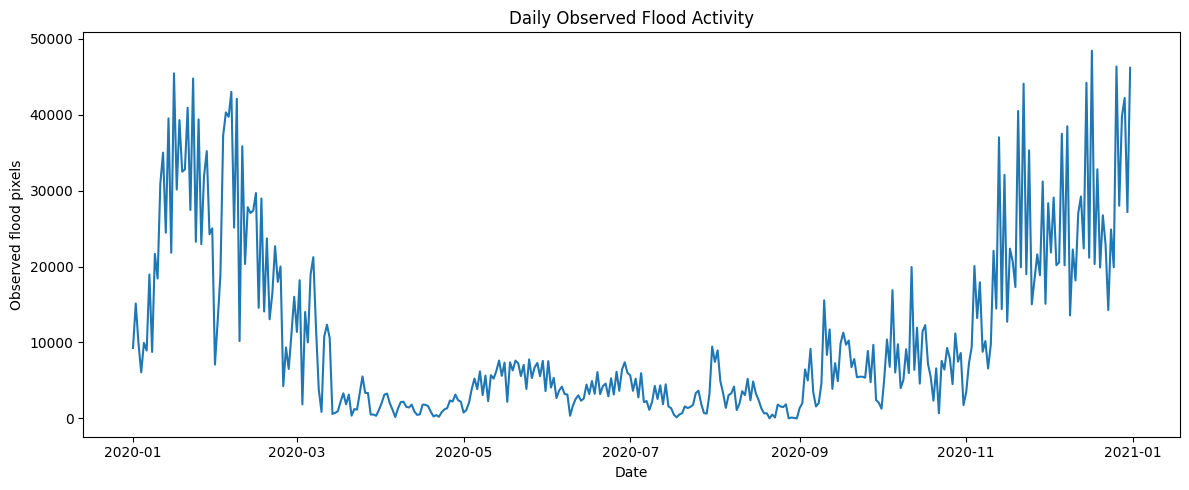

In [15]:
# Plot daily flood activity
plt.figure(figsize=(12, 5))

plt.plot(
    daily_flood.index,
    daily_flood.values
)

plt.xlabel("Date")
plt.ylabel("Observed flood pixels")

plt.title(
    "Daily Observed Flood Activity"
)

plt.tight_layout()
plt.show()

In [16]:
# Identify high flood days
flood_threshold = daily_flood.quantile(
    FLOOD_EVENT_PERCENTILE
)

high_flood_days = daily_flood[
    daily_flood >= flood_threshold
]

print("--- HIGH-FLOOD DAY DEFINITION ---")

print(
    f"Percentile threshold: "
    f"{FLOOD_EVENT_PERCENTILE * 100:.0f}%"
)

print(
    f"Flood threshold: "
    f"{flood_threshold:.0f} flood pixels"
)

print(
    f"\nNumber of high-flood days: "
    f"{len(high_flood_days)}"
)

print("\nFirst high-flood days:")
print(high_flood_days.head(15))

--- HIGH-FLOOD DAY DEFINITION ---
Percentile threshold: 75%
Flood threshold: 16782 flood pixels

Number of high-flood days: 92

First high-flood days:
date
2020-01-07    18955
2020-01-09    21669
2020-01-10    18426
2020-01-11    30938
2020-01-12    35016
2020-01-13    24455
2020-01-14    39522
2020-01-15    21826
2020-01-16    45453
2020-01-17    30145
2020-01-18    39299
2020-01-19    32506
2020-01-20    32801
2020-01-21    40926
2020-01-22    27459
Name: flood_pixels, dtype: int64


In [17]:
# Group high flood days into events
high_flood_df = high_flood_days.reset_index()

high_flood_df.columns = ["date", "flood_pixels"]

high_flood_df["days_since_previous"] = (
    high_flood_df["date"].diff().dt.days
)

high_flood_df["new_event"] = (
    high_flood_df["days_since_previous"] > 1
).fillna(True)

high_flood_df["event_id"] = (
    high_flood_df["new_event"].cumsum()
)

print("--- HIGH-FLOOD DAYS WITH EVENT IDS ---")
print(high_flood_df.head(30))

--- HIGH-FLOOD DAYS WITH EVENT IDS ---
         date  flood_pixels  days_since_previous  new_event  event_id
0  2020-01-07         18955                  NaN      False         0
1  2020-01-09         21669                  2.0       True         1
2  2020-01-10         18426                  1.0      False         1
3  2020-01-11         30938                  1.0      False         1
4  2020-01-12         35016                  1.0      False         1
5  2020-01-13         24455                  1.0      False         1
6  2020-01-14         39522                  1.0      False         1
7  2020-01-15         21826                  1.0      False         1
8  2020-01-16         45453                  1.0      False         1
9  2020-01-17         30145                  1.0      False         1
10 2020-01-18         39299                  1.0      False         1
11 2020-01-19         32506                  1.0      False         1
12 2020-01-20         32801                  1.0   

In [18]:
# Summarize high-flood events
flood_events = (
    high_flood_df
    .groupby("event_id")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        duration_days=("date", "count"),
        peak_flood_pixels=("flood_pixels", "max")
    )
)

peak_dates = (
    high_flood_df
    .loc[
        high_flood_df.groupby("event_id")["flood_pixels"].idxmax(),
        ["event_id", "date"]
    ]
    .set_index("event_id")
    .rename(columns={"date": "peak_date"})
)

flood_events = flood_events.join(peak_dates)
flood_events = flood_events[
    [
        "start_date",
        "end_date",
        "duration_days",
        "peak_date",
        "peak_flood_pixels"
    ]
]

print("--- FLOOD EVENT SUMMARY ---")
print(flood_events)
print("\nNumber of flood events:")
print(len(flood_events))

--- FLOOD EVENT SUMMARY ---
         start_date   end_date  duration_days  peak_date  peak_flood_pixels
event_id                                                                   
0        2020-01-07 2020-01-07              1 2020-01-07              18955
1        2020-01-09 2020-01-30             22 2020-01-16              45453
2        2020-02-02 2020-02-08              7 2020-02-06              43028
3        2020-02-10 2020-02-15              6 2020-02-10              35858
4        2020-02-17 2020-02-17              1 2020-02-17              28979
5        2020-02-19 2020-02-19              1 2020-02-19              23710
6        2020-02-22 2020-02-24              3 2020-02-22              22690
7        2020-03-02 2020-03-02              1 2020-03-02              18201
8        2020-03-06 2020-03-07              2 2020-03-07              21239
9        2020-10-05 2020-10-05              1 2020-10-05              16890
10       2020-10-12 2020-10-12              1 2020-10-12    

In [19]:
# Create daily meterological and hydrological variables 
tp_mm = era5["tp"] * 1000
ro_mm = era5["ro"] * 1000

tp_hourly_max = tp_mm.max(
    dim=["latitude", "longitude"]
)

ro_hourly_max = ro_mm.max(
    dim=["latitude", "longitude"]
)

daily_tp_max = tp_hourly_max.resample(
    valid_time="1D"
).max()

daily_ro_max = ro_hourly_max.resample(
    valid_time="1D"
).max()

daily_met_df = pd.DataFrame(
    {
        "precipitation_mm": daily_tp_max.values,
        "runoff_mm": daily_ro_max.values
    },
    index=pd.to_datetime(
        daily_tp_max["valid_time"].values
    )
)

daily_met_df.index.name = "date"

print("--- DAILY METEOROLOGICAL VARIABLES ---")
print(daily_met_df.head())

print("\nSummary statistics:")
print(daily_met_df.describe())

--- DAILY METEOROLOGICAL VARIABLES ---
            precipitation_mm  runoff_mm
date                                   
2020-01-01          3.345490   1.318932
2020-01-02          9.221554   4.561424
2020-01-03          9.266853   9.038925
2020-01-04         27.988434  27.356625
2020-01-05         16.024590  13.820648

Summary statistics:
       precipitation_mm   runoff_mm
count        366.000000  366.000000
mean          27.563082   23.997553
std           16.115543   16.884062
min            3.345490    1.318932
25%           12.321711    8.684099
50%           25.258780   20.768881
75%           39.601564   35.966873
max           71.634293   71.882248


In [20]:
# Extract conditions before each flood event

LOOKBACK_DAYS = 7
event_windows = []

for event_id, event in flood_events.iterrows():

    peak_date = pd.Timestamp(event["peak_date"])
    window_start = peak_date - pd.Timedelta(
        days=LOOKBACK_DAYS
    )
    window_end = peak_date - pd.Timedelta(
        days=1
    )
    event_window = daily_met_df.loc[
        window_start:window_end
    ].copy()
    event_window["days_before_peak"] = range(
        -len(event_window),
        0
    )
    event_window["event_id"] = event_id
    event_window["peak_date"] = peak_date
    event_window["peak_flood_pixels"] = (
        event["peak_flood_pixels"]
    )
    event_windows.append(event_window)
event_windows_df = pd.concat(event_windows)

print("--- CONDITIONS BEFORE FLOOD EVENT PEAKS ---")
print(event_windows_df.head(20))
print("\nTotal observations:")
print(len(event_windows_df))

--- CONDITIONS BEFORE FLOOD EVENT PEAKS ---
            precipitation_mm  runoff_mm  days_before_peak  event_id  \
date                                                                  
2020-01-01          3.345490   1.318932                -6         0   
2020-01-02          9.221554   4.561424                -5         0   
2020-01-03          9.266853   9.038925                -4         0   
2020-01-04         27.988434  27.356625                -3         0   
2020-01-05         16.024590  13.820648                -2         0   
2020-01-06         21.719933  14.381409                -1         0   
2020-01-09         19.037247  11.282921                -7         1   
2020-01-10         36.006927  31.936646                -6         1   
2020-01-11         10.022640   6.427765                -5         1   
2020-01-12         45.816422  43.118477                -4         1   
2020-01-13         53.622246  51.893234                -3         1   
2020-01-14         20.675659  19.

In [21]:
# Average pattern before flood events

average_pre_event_pattern = (
    event_windows_df
    .groupby("days_before_peak")
    .agg(
        precipitation_mean_mm=("precipitation_mm", "mean"),
        precipitation_median_mm=("precipitation_mm", "median"),
        runoff_mean_mm=("runoff_mm", "mean"),
        runoff_median_mm=("runoff_mm", "median"))
)
print("--- AVERAGE CONDITIONS BEFORE FLOOD PEAKS ---")
print(average_pre_event_pattern)

--- AVERAGE CONDITIONS BEFORE FLOOD PEAKS ---
                  precipitation_mean_mm  precipitation_median_mm  \
days_before_peak                                                   
-7                            23.753714                20.684242   
-6                            25.014559                17.763138   
-5                            17.488865                11.393070   
-4                            25.197371                21.753311   
-3                            17.662525                12.047768   
-2                            22.979349                20.675659   
-1                            22.351196                17.956734   

                  runoff_mean_mm  runoff_median_mm  
days_before_peak                                    
-7                     19.505655         16.379118  
-6                     21.859430         13.613224  
-5                     13.053111          8.138895  
-4                     20.853519         15.707970  
-3                     

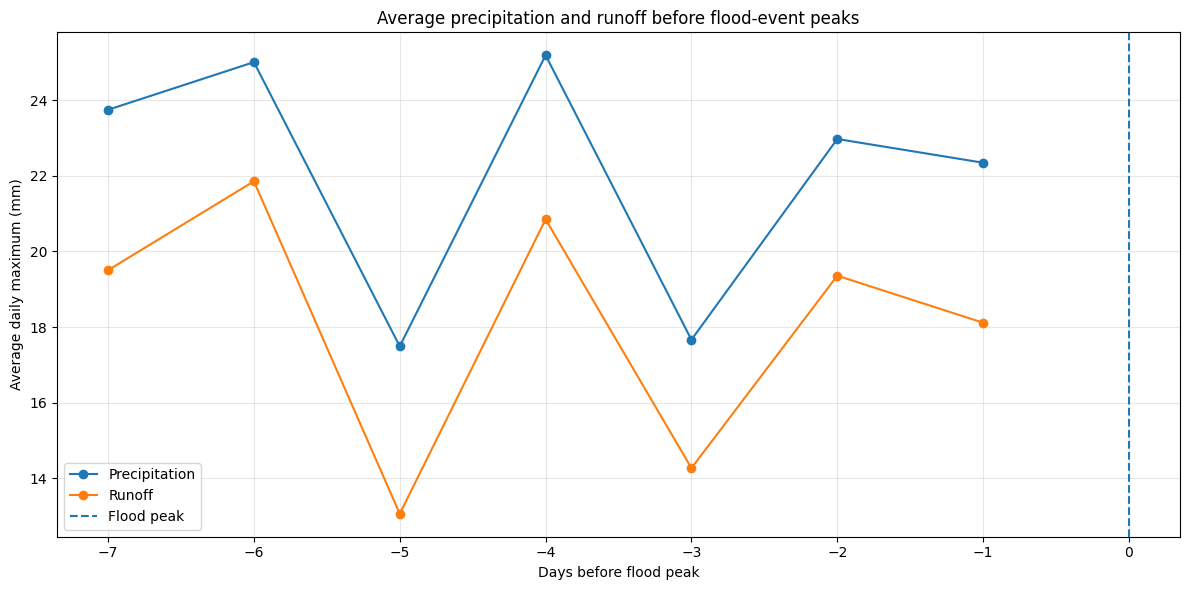

In [22]:
# Plot average conditions before flood peaks
plt.figure(figsize=(12, 6))
plt.plot(
    average_pre_event_pattern.index,
    average_pre_event_pattern["precipitation_mean_mm"],
    marker="o",
    label="Precipitation"
)
plt.plot(
    average_pre_event_pattern.index,
    average_pre_event_pattern["runoff_mean_mm"],
    marker="o",
    label="Runoff"
)
plt.axvline(x=0, linestyle="--", label="Flood peak")
plt.xlabel("Days before flood peak")
plt.ylabel("Average daily maximum (mm)")
plt.title("Average precipitation and runoff before flood-event peaks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Compare average conditions before flood peaks with overall conditions

overall_precip_mean = daily_met_df["precipitation_mm"].mean()
overall_runoff_mean = daily_met_df["runoff_mm"].mean()

comparison_df = average_pre_event_pattern[[
    "precipitation_mean_mm",
    "runoff_mean_mm"
]].copy()

comparison_df["precipitation_difference_from_overall"] = (
    comparison_df["precipitation_mean_mm"] - overall_precip_mean
)

comparison_df["runoff_difference_from_overall"] = (
    comparison_df["runoff_mean_mm"] - overall_runoff_mean
)

print("--- COMPARISON WITH OVERALL CONDITIONS ---")
print(f"Overall mean precipitation: {overall_precip_mean:.2f} mm")
print(f"Overall mean runoff: {overall_runoff_mean:.2f} mm")

print("\nConditions before flood peaks:")
print(comparison_df)

--- COMPARISON WITH OVERALL CONDITIONS ---
Overall mean precipitation: 27.56 mm
Overall mean runoff: 24.00 mm

Conditions before flood peaks:
                  precipitation_mean_mm  runoff_mean_mm  \
days_before_peak                                          
-7                            23.753714       19.505655   
-6                            25.014559       21.859430   
-5                            17.488865       13.053111   
-4                            25.197371       20.853519   
-3                            17.662525       14.263494   
-2                            22.979349       19.359077   
-1                            22.351196       18.113874   

                  precipitation_difference_from_overall  \
days_before_peak                                          
-7                                            -3.809368   
-6                                            -2.548523   
-5                                           -10.074217   
-4                             

**Answer to RQ5: What temporal patterns in meteorological and hydrological variables consistently precede observed events?**

To investigate temporal patterns preceding flood events, high-flood days were first identified as days above the 75th percentile of daily flood activity, corresponding to 16,782 flood pixels. Consecutive high-flood days were then grouped into flood events, resulting in 21 flood events during 2020. For each event, the date with the highest number of flood pixels was defined as the flood-event peak.

Precipitation and runoff were subsequently examined during the seven days preceding each flood-event peak. The average temporal pattern across all 21 events showed substantial fluctuations in both variables rather than a clear, steady increase towards the flood peak. For example, mean precipitation ranged from approximately 17.5 mm to 25.2 mm during the seven days before a flood peak, while mean runoff ranged from approximately 13.1 mm to 21.9 mm.

Both precipitation and runoff were relatively elevated during the final two days before the flood peak compared with some earlier days in the seven-day window. Mean precipitation was approximately 23.0 mm two days before the peak and 22.4 mm one day before the peak, while mean runoff was approximately 19.4 mm and 18.1 mm, respectively. However, this increase was not sufficiently strong or consistent to indicate a clear short-term precursor pattern.

When these pre-event conditions were compared with average conditions across the full year, an important pattern emerged. The overall mean precipitation during 2020 was 27.56 mm, while the overall mean runoff was 24.00 mm. All seven pre-event days had average precipitation and runoff values below these overall averages. Therefore, although precipitation and runoff sometimes remained relatively elevated immediately before flood peaks compared with other days in the pre-event period, they were not consistently unusually high compared with typical conditions during the year.

Overall, the analysis does not identify a single consistent temporal pattern or fixed advance-warning period in maximum daily precipitation and runoff preceding observed flood-event peaks. Neither variable showed a steady increase as the flood peak approached. This suggests that, at the spatial and temporal aggregation used in this analysis, precipitation and runoff alone do not provide a universal meteorological or hydrological precursor for the observed flood events. Flood occurrence and peak extent may therefore depend on additional factors, including the spatial location and timing of rainfall, accumulated antecedent conditions, and the persistence and development of individual flood events